In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import empty
import xarray as xr
import pftnames
import cftime
import utils
import grainc_global
from scipy import stats, signal
import HS_functions
import cartopy.crs as ccrs
import regionmask
import glob
import os
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm
import matplotlib.colors as mcolors
import cartopy.feature as cfeature

79


In [2]:
def merge_annual_datasets(path_in, YR1, YR2, historyfile='h1', cft=None, var='ELAI'):
    # find relevant files
    pattern = os.path.join(path_in, f"*clm2.{historyfile}.*.nc")
    files_all = sorted(glob.glob(pattern))

    if len(files_all) == 0:
        raise FileNotFoundError(f"No files found matching pattern {pattern}")

    files = []
    for f in files_all:
        try:
            year = int(f.split('.')[-2].split('-')[0])
            if YR1 <= year <= YR2:
                files.append(f)
        except Exception:
            continue

    if len(files) == 0:
        raise ValueError(f"No files found between {YR1} and {YR2}")
    elif len(files) < (YR2-YR1):
        raise ValueError(f"years not matching number of files")
        
    # open and append files      
    ds_list = []
    print(var)
    for f in files:
        print(int(f.split('.')[-2].split('-')[0]))
        ds = xr.open_dataset(f)
        ds_var = ds[var]
        dim = len(ds_var.shape)
        if dim == 3:
            ds_list.append(ds_var)
        elif dim == 2:
            # pft to grid
            #ds_var['pft1d_itype_veg_str'] = np.array(pftnames.pftname)[ds_var['pfts1d_itype_veg'].values.astype(int)]
            ds_var = grainc_global.reshape_1D_to_2Dgrid(var, ds, mask =None)
            ds_var = ds_var.rename({'pft':'cft'})
            ds_var_crop = ds_var.sel(cft=cft)
            
            # merge files into on xarray based on var and crop
            ds_list.append(ds_var_crop)
        else:
            print('error: check dimensions')
            ds.close()
            del ds
            continue

        ds.close()
        del ds
        del ds_var
            
    da_out = xr.concat(ds_list, dim="time")
    da_out = da_out.sortby("time")
    da_out = utils.lon_pm2idl(da_out)
    
    return da_out

In [3]:
def merge_annual_datasets_multivar(path_in, YR1, YR2, historyfile='h0'):

    # --------------------------------------------------
    # Find files
    # --------------------------------------------------
    pattern = os.path.join(path_in, f"*clm2.{historyfile}.*.nc")
    files_all = sorted(glob.glob(pattern))

    if len(files_all) == 0:
        raise FileNotFoundError(f"No files found matching {pattern}")

    files = []
    for f in files_all:
        try:
            year = int(f.split('.')[-2].split('-')[0])
            if YR1 <= year <= YR2:
                files.append(f)
        except Exception:
            continue

    if len(files) == 0:
        raise ValueError(f"No files found between {YR1} and {YR2}")

    # --------------------------------------------------
    # Open datasets
    # --------------------------------------------------
    datasets = [xr.open_dataset(f) for f in files]

    # --------------------------------------------------
    # Concatenate ALL variables safely
    # --------------------------------------------------
    ds_merged = xr.concat(
        datasets,
        dim="time",
        data_vars="all",      # <-- key: include all variables
        coords="all",
        compat="override",    # avoid metadata conflicts
        join="outer"          # allow missing variables
    )

    return ds_merged

In [4]:
root        = f''
path_lai    = f'{root}/apps/CTSM_dev/DERECHO_OUT/harmonized_exps_lai_rep/LAI5'
path_rep    = f'{root}/apps/CTSM_dev/DERECHO_OUT/harmonized_exps_lai_rep/REP5'
path_ref    = f'{root}/apps/CTSM_dev/DERECHO_OUT/ihist.e52.IHistClm50BgcCrop.f19_g17.nostress_1980/'
crop_list   = ['spring_wheat', 'temperate_corn','tropical_corn', 'rice', 'soybean', 'tropical_soybean', 'cotton']
croplist_ir = ['irrigated_spring_wheat', 'irrigated_temperate_corn', 'irrigated_tropical_corn', 'irrigated_rice', 'irrigated_soybean','irrigated_tropical_soybean', 'irrigated_cotton']
YR1, YR2     = 1985, 2014
VARS         = ['ELAI', 'NPP']



In [5]:
# LAIEXP
ds_lai = merge_annual_datasets(
    path_lai,
    YR1,
    YR2,
    historyfile='h3',
    cft= crop_list + croplist_ir,
    var='ELAI'
)
ds_lai_npp = merge_annual_datasets(
    path_lai,
    YR1,
    YR2,
    historyfile='h3',
    cft= crop_list + croplist_ir,
    var='NPP'
)

ELAI
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
NPP
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014


In [6]:
ds_ref = merge_annual_datasets(
    path_ref,
    YR1,
    YR2,
    historyfile='h3',
    cft= crop_list + croplist_ir,
    var='ELAI'
)
ds_ref_npp = merge_annual_datasets(
    path_ref,
    YR1,
    YR2,
    historyfile='h3',
    cft= crop_list + croplist_ir,
    var='NPP'
)

ELAI
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
NPP
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014


In [7]:
ds_rep = merge_annual_datasets(
    path_rep,
    YR1,
    YR2,
    historyfile='h3',
    cft= crop_list + croplist_ir,
    var='ELAI'
)

ds_rep_npp = merge_annual_datasets(
    path_rep,
    YR1,
    YR2,
    historyfile='h3',
    cft= crop_list + croplist_ir,
    var='NPP'
)

ELAI
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
NPP
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014


In [ ]:
# calculate percentage difference in LAI and GPP per crop

In [9]:
def calc_perentage(ds, ds_ref):
    ds = ds.where(ds >0.002)
    ds_ref = ds_ref.where(ds_ref>0.002)
    percentage = ((ds - ds_ref)/ds_ref)*100
    return percentage

In [78]:
#LAI ds
ds_rep_lai_ann = (ds_rep).groupby("time.year").max("time")
ds_ref_lai_ann = (ds_ref).groupby("time.year").max("time")
ds_lai_lai_ann = (ds_lai).groupby("time.year").max("time")

In [11]:
#NPP ds
#ds_rep_npp_ann = (ds_rep_npp*86400).groupby("time.year").sum("time")
ds_ref_npp_ann = (ds_ref_npp*86400).groupby("time.year").sum("time")
ds_lai_npp_ann = (ds_lai_npp*86400).groupby("time.year").sum("time")

In [79]:
# CORN
ref = ds_ref_lai_ann[:,[1,2],:,:].sum(dim='cft').where(ds_ref_lai_ann[:,[1,2],:,:].sum(dim='cft')>0)
exp = ds_rep_lai_ann[:,[1,2],:,:].sum(dim='cft').where(ds_ref_lai_ann[:,[1,2],:,:].sum(dim='cft')>0)
t = (exp - ref).where(ref > 0)
percentage_map =  (t).max(dim='year')
#percentage_map = (t / ref).max("year") * 100
#bounds = [0,0.1,5,10,20,50,80]
#percentage.max(dim='year').plot(vmin=0, vmax=10)

In [86]:
cropix = 0
ref = ds_ref_lai_ann[:,cropix,:,:].where(ds_ref_lai_ann[:,cropix,:,:]>0)
exp = ds_rep_lai_ann[:,cropix,:,:].where(ds_ref_lai_ann[:,cropix,:,:]>0)
t = (exp - ref).where(ref > 0)
percentage_map =  (t).max(dim='year')

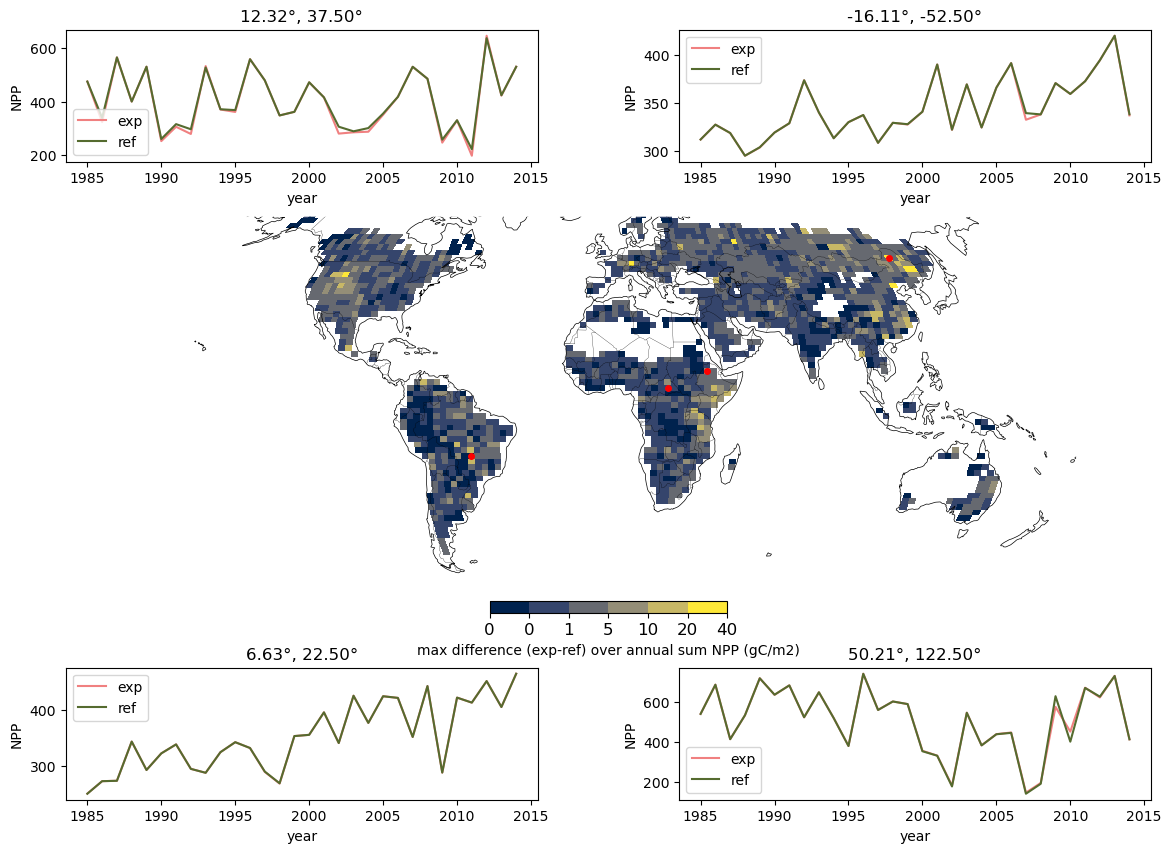

In [16]:


# =========================================================
# 3. COLORMAP
# =========================================================
bounds = [0, 0.1,1, 5, 10, 20, 40]
cmap = plt.cm.cividis
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================================================
# 4. FIGURE LAYOUT
# =========================================================
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    3, 1,
    height_ratios=[1, 3, 1],
    hspace=0.25
)

# =========================================================
# 5. MAP
# =========================================================
ax_map = fig.add_subplot(gs[1, 0], projection=ccrs.Robinson())

im = ax_map.pcolormesh(
    percentage_map.lon,
    percentage_map.lat,
    percentage_map,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm
)

ax_map.set_global()
ax_map.set_extent([-180, 180, -60, 65], crs=ccrs.PlateCarree())

ax_map.spines['geo'].set_visible(False)
ax_map.coastlines(linewidth=0.5)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.2)

cbar = plt.colorbar(
    im,
    ax=ax_map,
    orientation="horizontal",
    pad=0.04,
    fraction=0.03,   # ↓ smaller bar (try 0.02–0.05)
    shrink=0.6       # optional extra scaling
)
cbar.set_label("max difference (exp-ref) over annual sum NPP (gC/m2)")
cbar.ax.tick_params(labelsize=12)
cbar.set_ticks(bounds)
cbar.set_ticklabels([str(int(b)) for b in bounds])

# =========================================================
# 6. VALID PIXELS (FROM SAME GRID AS MAP)
# =========================================================
# mask_map = np.isfinite(percentage_map.values)
ts_var = (exp / ref).std(dim="year")
mask_map = np.isfinite(ts_var.values)
valid = (
    (ref.isel(year=0) > 0) &
    np.isfinite(exp.isel(year=0)) &
    np.isfinite(ref.isel(year=0))
)

#lat_i, lon_i = np.where(mask_map)
lat_i, lon_i = np.where(valid.values)
rix = 550
np.random.seed(rix)#3
rand_idx = np.random.choice(len(lat_i), 3, replace=False)
rand_pixels = [(lat_i[i], lon_i[i]) for i in rand_idx]

# =========================================================
# 7. HOT PIXEL (>50%)
# =========================================================
hot = np.where(percentage_map.values > 30)

if len(hot[0]) > 0:
    i = np.random.choice(len(hot[0]))
    special_pixel = (hot[0][i], hot[1][i])
else:
    special_pixel = rand_pixels[0]

all_pixels = rand_pixels + [special_pixel]

# =========================================================
# 8. MAP MARKERS
# =========================================================
for (li, lj) in all_pixels:
    ax_map.plot(
        percentage_map.lon.values[lj],
        percentage_map.lat.values[li],
        marker='o',
        markersize=4,
        color='red',
        transform=ccrs.PlateCarree()
    )

# =========================================================
# 9. TIME SERIES LAYOUT
# =========================================================
gs_top = gs[0, 0].subgridspec(1, 2, wspace=0.3)
ax_t1 = fig.add_subplot(gs_top[0, 0])
ax_t2 = fig.add_subplot(gs_top[0, 1])

gs_bot = gs[2, 0].subgridspec(1, 2, wspace=0.3)
ax_t3 = fig.add_subplot(gs_bot[0, 0])
ax_t4 = fig.add_subplot(gs_bot[0, 1])

# =========================================================
# 10. TIME SERIES FUNCTION (USES SAME exp/ref)
# =========================================================
def plot_ts(ax, li, lj):
    exp_ts = exp.isel(lat=li, lon=lj)
    ref_ts = ref.isel(lat=li, lon=lj)

    exp_ts.plot(ax=ax, label="exp", color='lightcoral')
    ref_ts.plot(ax=ax, label="ref", color='darkolivegreen')

    ax.set_title(f"{float(exp_ts.lat.values):.2f}°, {float(exp_ts.lon.values):.2f}°")
    ax.legend()

# =========================================================
# 11. PLOT TIME SERIES
# =========================================================
plot_ts(ax_t1, *rand_pixels[0])
plot_ts(ax_t2, *rand_pixels[1])
plot_ts(ax_t3, *rand_pixels[2])
plot_ts(ax_t4, *special_pixel)

# =========================================================
# 12. SHOW
# =========================================================

plt.savefig(f'{root}/paper1/figs/NPP_annualsum_EXPLAI5_set{rix}_{crop_list[cropix]}.jpeg',dpi=400)#{crop_list[cropix]}
plt.show()

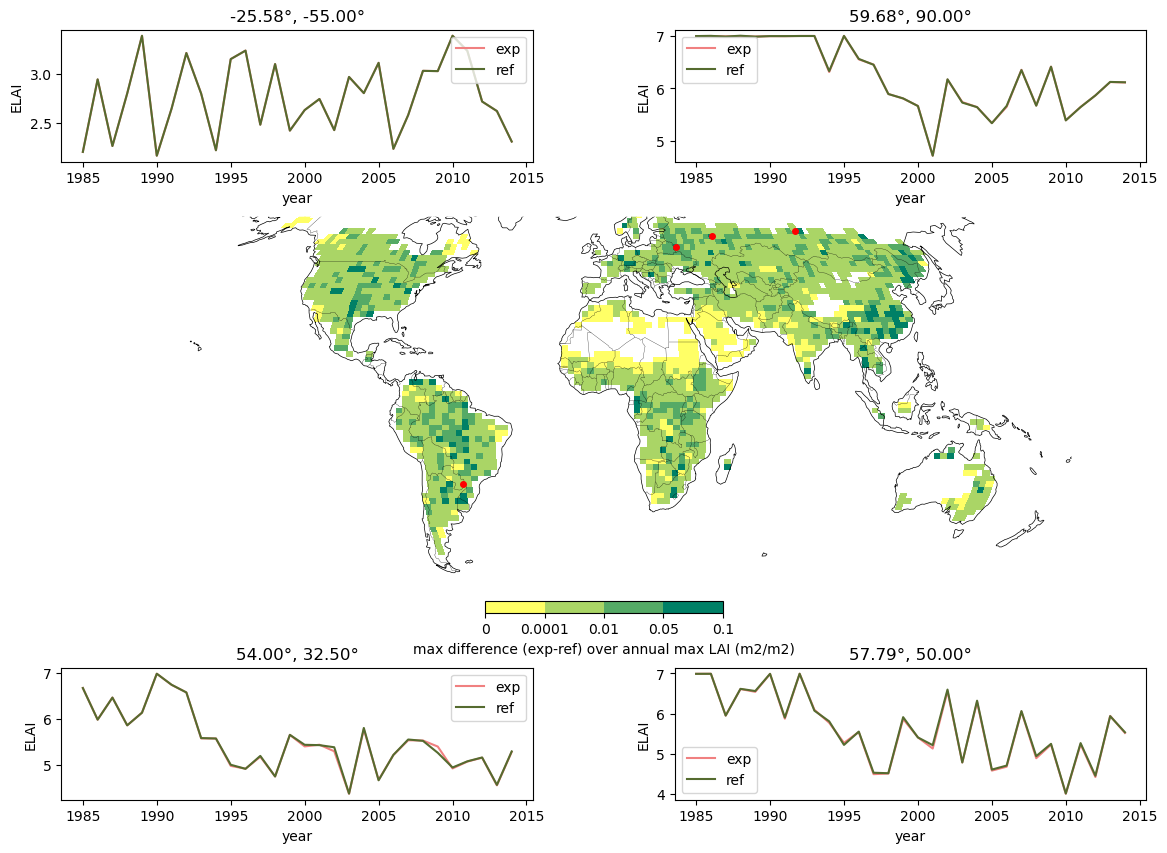

In [91]:


# =========================================================
# 3. COLORMAP
# =========================================================

bounds = [0,0.0001,0.01,0.05,0.1]
cmap = plt.cm.summer_r#BrBG
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# =========================================================
# 4. FIGURE LAYOUT
# =========================================================
fig = plt.figure(figsize=(14, 10))

gs = fig.add_gridspec(
    3, 1,
    height_ratios=[1, 3, 1],
    hspace=0.25
)

# =========================================================
# 5. MAP
# =========================================================
ax_map = fig.add_subplot(gs[1, 0], projection=ccrs.Robinson())

im = ax_map.pcolormesh(
    percentage_map.lon,
    percentage_map.lat,
    percentage_map,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm
)

ax_map.set_global()
ax_map.set_extent([-180, 180, -60, 65], crs=ccrs.PlateCarree())

ax_map.spines['geo'].set_visible(False)
ax_map.coastlines(linewidth=0.5)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.2)

cbar = plt.colorbar(
    im,
    ax=ax_map,
    orientation="horizontal",
    pad=0.04,
    fraction=0.03
)
cbar.set_label("max difference (exp-ref) over annual max LAI (m2/m2)")
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks(bounds)
cbar.set_ticklabels([str(b) for b in bounds])

# =========================================================
# 6. VALID PIXELS (FROM SAME GRID AS MAP)
# =========================================================
# mask_map = np.isfinite(percentage_map.values)
ts_var = (exp / ref).std(dim="year")
mask_map = np.isfinite(ts_var.values)
valid = (
    (ref.isel(year=0) > 0) &
    np.isfinite(exp.isel(year=0)) &
    np.isfinite(ref.isel(year=0))
)

#lat_i, lon_i = np.where(mask_map)
lat_i, lon_i = np.where(valid.values)
rix = 1500
np.random.seed(rix)#3
rand_idx = np.random.choice(len(lat_i), 2, replace=False)
rand_pixels = [(lat_i[i], lon_i[i]) for i in rand_idx]

# =========================================================
# 7. specificm pixels
# =========================================================
lailoss  = (t).mean(dim='year')
hot = np.where(percentage_map.values > 0.07)
cold = np.where(lailoss .values <-0.01)

if len(hot[0]) > 0:
    i = np.random.choice(len(hot[0]))
    special_pixel = (hot[0][i], hot[1][i])
else:
    special_pixel = rand_pixels[0]

if len(cold[0]) > 0:
    i = np.random.choice(len(cold[0]))
    special_pixel2 = (cold[0][i], cold[1][i])
else:
    special_pixel2 = rand_pixels[0]

all_pixels = rand_pixels + [special_pixel] + [special_pixel2] 

# =========================================================
# 8. MAP MARKERS
# =========================================================
for (li, lj) in all_pixels:
    ax_map.plot(
        percentage_map.lon.values[lj],
        percentage_map.lat.values[li],
        marker='o',
        markersize=4,
        color='red',
        transform=ccrs.PlateCarree()
    )

# =========================================================
# 9. TIME SERIES LAYOUT
# =========================================================
gs_top = gs[0, 0].subgridspec(1, 2, wspace=0.3)
ax_t1 = fig.add_subplot(gs_top[0, 0])
ax_t2 = fig.add_subplot(gs_top[0, 1])

gs_bot = gs[2, 0].subgridspec(1, 2, wspace=0.3)
ax_t3 = fig.add_subplot(gs_bot[0, 0])
ax_t4 = fig.add_subplot(gs_bot[0, 1])

# =========================================================
# 10. TIME SERIES FUNCTION (USES SAME exp/ref)
# =========================================================
def plot_ts(ax, li, lj):
    exp_ts = exp.isel(lat=li, lon=lj)
    ref_ts = ref.isel(lat=li, lon=lj)

    exp_ts.plot(ax=ax, label="exp", color='lightcoral')
    ref_ts.plot(ax=ax, label="ref", color='darkolivegreen')

    ax.set_title(f"{float(exp_ts.lat.values):.2f}°, {float(exp_ts.lon.values):.2f}°")
    ax.legend()

# =========================================================
# 11. PLOT TIME SERIES
# =========================================================
plot_ts(ax_t1, *rand_pixels[0])
plot_ts(ax_t2, *rand_pixels[1])
plot_ts(ax_t3, *special_pixel)
plot_ts(ax_t4, *special_pixel2)

# =========================================================
# 12. SHOW
# =========================================================

plt.savefig(f'{root}/paper1/figs/LAImx_EXPREP5_set{rix}_{crop_list[cropix]}.jpeg',dpi=400)#{crop_list[cropix]}
plt.show()